# Глубинное обучение для текстовых данных, ФКН ВШЭ
## Retrieval‑Augmented Generation (RAG)

### О проекте

В этом проекте реализован ассистент для кулинарных советов с помощью RAG, который помимо всего прочего может ходить в итернет за дополнительной информацией. Вся логика системы написана самостоятельно без специализорованных библиотек. Проект разделен на несколько логических компонент:
1. Векторная база данных с быстрым семантическим поиском
2. Разбиение текстов на куски.
3. Ранжирование документов по релевантности
4. Формирование контекста для модели и генерация ответа

### О данных

В качестве базы данных мы будем использовать пользовательские рецепты с сайта "Поваренок.Ру". Они получены с помощью веб-парсинга сайта, поэтому местами тексты недостаточно чистые. Всего в датасете содержится 84130 рецептов.

In [ ]:
!pip install --upgrade --no-cache-dir \
  "numpy<1.24" \
  "torch>=2.0,<2.4" \
  "transformers==4.39.3" \
  "accelerate==0.28.0" \
  "bitsandbytes==0.43.1" \
  "datasets==2.19.0" \
  "sentence-transformers==2.6.1" \
  "beautifulsoup4==4.12.3" \
  "requests>=2.31.0"


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from __future__ import annotations

### Загрузка датасета и модели

Таблица с рецептами хранится в файле `povarenok.csv`. Каждая запись содержит название рецепта, список ингредиентов и сам рецепт. Несмотря на то, что всего датасете хранится 84130 записей, в рамках этого задания мы будем работать с первыми 10-ю тысячами для того, чтобы все работало быстрее.

In [ ]:
from datasets import load_dataset

dataset = load_dataset('csv', data_files=['./povarenok.csv'], split='train')
dataset = dataset.select(range(10000))
dataset

Dataset({
    features: ['name', 'ingredients', 'text'],
    num_rows: 10000
})

In [ ]:
dataset[0]

{'name': 'Густой молочно-клубничный коктейль',
 'ingredients': "['Молоко', 'Клубника', 'Сахар']",
 'text': 'Не размораживая, ягоду положите в блендер, добавьте молоко и сахар (если ягода свежая, то и перепелиное яйцо) Взбивайте на высокой скорости до полного измельчения ягод. Вылете в стаканы и можно по чуть-чуть пить, так как этот напиток оочень холодный. Кто не любит таковой, подождите и выпейте, когда он немного согреется. Приятного аппетита!'}

Посмотрим на распределение длин текстов. Нам важно знать с чем мы имеем дело, ведь RAG подразумевает, что мы будем подавать тексты на вход модели.

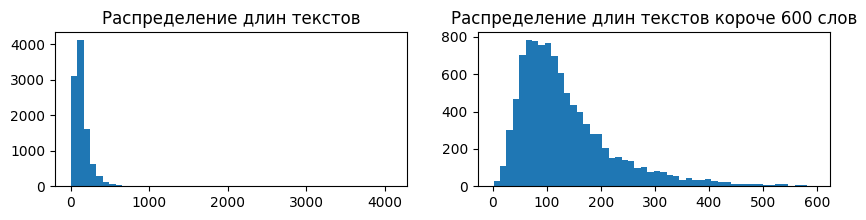

In [ ]:
lens = np.array([len(dataset[i]['text'].split()) for i in range(len(dataset))])

plt.figure(figsize=(10, 2))
plt.subplot(1, 2, 1)
plt.hist(lens, bins=50)
plt.title('Распределение длин текстов')

plt.subplot(1, 2, 2)
plt.hist(lens[lens < 600], bins=50)
plt.title('Распределение длин текстов короче 600 слов')

plt.show()

Видим, что тексты часто довольно длинные. Поэтому смухлевать не получится и перед векторизацией нужно будет разбивать каждый текст на небольшие куски, чтобы не перегружать контекст модели и чтобы потерять важную информацию при векторизацци текстов на этапе складывания их в векторную базу данных.

Приступим к реализации RAG.

## Retrieval‑Augmented Generation

В качестве основы для ассистента взята модель [`Qwen/Qwen2-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2-1.5B-Instruct) из huggingface. Важно, что это `Instruct` модель, то есть она предлазначена для общения в формате диалога.

Проверим, как модель отвечает на кулинарные вопросы без RAG. Это необходимо сделать, чтобы понять, нужен ли вообще RAG для данной задачи.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, AutoModel

MODEL_NAME = "Qwen/Qwen2-1.5B-Instruct"
DEVICE = 0 if torch.cuda.is_available() else "cpu"
LOAD_4BIT = True

if LOAD_4BIT:
    from transformers import BitsAndBytesConfig
    bnb_cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                 bnb_4bit_use_double_quant=True)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        device_map="auto",
        quantization_config=bnb_cfg,
        trust_remote_code=True
    )
else:
    torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        torch_dtype=torch_dtype,
        device_map="auto",
        trust_remote_code=True
    )

tok = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, trust_remote_code=True)

questions = [
    "У меня есть яйца, рис и морковь. Что быстро приготовить на ужин?",
    "Сколько варить гречку, чтобы она получилась рассыпчатой?",
    "Как приготовить пирог с мясом?"
]

def chat_infer(prompt, max_new_tokens=256, temperature=0.2, top_p=0.9):
    messages = [
        {"role": "system", "content": "You are a concise Russian cooking assistant. Answer in Russian."},
        {"role": "user", "content": prompt}
    ]
    input_ids = tok.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(model.device)

    attention_mask = torch.ones_like(input_ids)

    gen_ids = model.generate(
        input_ids,
        attention_mask=attention_mask,
        max_new_tokens=max_new_tokens,
        do_sample=temperature > 0,
        temperature=temperature,
        top_p=top_p,
        pad_token_id=tok.eos_token_id
    )
    out = tok.decode(gen_ids[0], skip_special_tokens=True)
    if "assistant" in out:
        out = out.split("assistant")[-1].strip()
    return out

print(f"Model: {MODEL_NAME} | Device: {DEVICE} | 4bit: {LOAD_4BIT}")
for i, q in enumerate(questions, 1):
    ans = chat_infer(q)
    print(f"\nQ{i}: {q}\nA{i}: {ans}\n" + "-"*80)


/home/user/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Model: Qwen/Qwen2-1.5B-Instruct | Device: 0 | 4bit: True


/home/user/.local/lib/python3.8/site-packages/bitsandbytes/nn/modules.py:426: UserWarning: Input type into Linear4bit is torch.float16, but bnb_4bit_compute_dtype=torch.float32 (default). This will lead to slow inference or training speed.
  warnings.warn(



Q1: У меня есть яйца, рис и морковь. Что быстро приготовить на ужин?
A1: Вы можете приготовить простой суп из этих ингредиентов: 

1. Возьмите 2-3 стакана воды.
2. Взбейте яйца в отдельной посуде.
3. Добавьте взбитые яйца в воду, постоянно помешивая, чтобы не образовались комочки.
4. Добавьте рис и морковь, перемешайте до однородности.

Это простое и быстрое блюдо готово!
--------------------------------------------------------------------------------

Q2: Сколько варить гречку, чтобы она получилась рассыпчатой?
A2: Варите гречку на медленном огне около 15-20 минут, пока она не станет мягким и рассыпчатым.
--------------------------------------------------------------------------------

Q3: Как приготовить пирог с мясом?
A3: Для приготовления пирога с мясом вам понадобится следующий список ингредиентов:

- 200 г свиного филе
- 100 г куриных яиц
- 50 г томатного соуса
- 50 г чеснока
- 30 г луковых зеленых листьев
- 1 стакан муки
- 1 стакан молока
- Соль и перец по вкусу

Составьте пиро

### Locality Sensitive Hashing (LSH)

Реализуем векторную базу данных LSH поиском. База данных должна уметь добавлять новые векторы, а так же по входному вектору быстро находить ближайшие к нему. Во время создании базы данных сгенерируем необходимое число хеш-функций.

In [ ]:
import time
from typing import List, Tuple


class LSHIndex:
    def __init__(
        self,
        dim: int,
        n_tables: int = 10,
        n_planes: int = 12,
        random_state: int | None = None,
    ):
        self.dim = dim
        self.n_tables = n_tables
        self.n_planes = n_planes

        rng = np.random.default_rng(random_state)
        self.hyperplanes = rng.normal(size=(n_tables, n_planes, dim)).astype(
            np.float32
        )

        self.tables: List[dict[int, List[int]]] = [dict() for _ in range(n_tables)]
        self.vectors: List[np.ndarray] = []

        self._bit_weights = (1 << np.arange(n_planes, dtype=np.uint64)).reshape(
            1, -1
        )

    def _hash_vector(self, v: np.ndarray) -> np.ndarray:
        v = v.astype(np.float32, copy=False)
        projections = np.tensordot(self.hyperplanes, v, axes=[2, 0])
        bits = (projections >= 0).astype(np.uint8)
        hashes = (bits * self._bit_weights).sum(axis=1).astype(np.uint64)
        return hashes

    def add(self, v: np.ndarray) -> int:
        v = np.asarray(v, dtype=np.float32)

        idx = len(self.vectors)
        self.vectors.append(v)

        hashes = self._hash_vector(v)
        for t, h in enumerate(hashes):
            bucket = self.tables[t].setdefault(int(h), [])
            bucket.append(idx)

        return idx

    def add_many(self, X: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        assert X.shape[1] == self.dim
        for v in X:
            self.add(v)

    def query(self, q: np.ndarray, top_n: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        q = np.asarray(q, dtype=np.float32)
        hashes = self._hash_vector(q)

        candidate_ids: set[int] = set()
        for t, h in enumerate(hashes):
            bucket = self.tables[t].get(int(h))
            if bucket:
                candidate_ids.update(bucket)

        if not candidate_ids:
            candidate_ids = set(range(len(self.vectors)))

        cand_idx = np.fromiter(candidate_ids, dtype=np.int32)
        cand_vecs = np.stack([self.vectors[i] for i in cand_idx], axis=0)

        diff = cand_vecs - q
        dists = np.einsum("ij,ij->i", diff, diff)  # L2^2
        order = np.argsort(dists)[:top_n]

        return cand_idx[order], dists[order]

    def brute_force(
        self, q: np.ndarray, top_n: int = 5
    ) -> Tuple[np.ndarray, np.ndarray]:
        q = np.asarray(q, dtype=np.float32)
        if not self.vectors:
            return np.array([], dtype=int), np.array([], dtype=np.float32)

        best: List[Tuple[float, int]] = []
        for idx, v in enumerate(self.vectors):
            diff = v - q
            d = float(np.dot(diff, diff))
            best.append((d, idx))

        best.sort(key=lambda x: x[0])
        top = best[:top_n]
        idxs = np.array([b[1] for b in top], dtype=np.int32)
        dists = np.array([b[0] for b in top], dtype=np.float32)
        return idxs, dists


np.random.seed(0)
n_points = 1000
dim = 2

points = np.random.randn(n_points, dim).astype(np.float32)

lsh = LSHIndex(dim=dim, n_tables=10, n_planes=12, random_state=42)
lsh.add_many(points)

n_queries = 200
query_indices = np.random.choice(n_points, size=n_queries, replace=False)

hits = 0
for idx in query_indices:
    q = points[idx]
    brute_idx, _ = lsh.brute_force(q, top_n=1)
    lsh_idx, _ = lsh.query(q, top_n=5)
    if brute_idx[0] in lsh_idx:
        hits += 1

recall = hits / n_queries
print(f"Доля запросов, где точный ближайший сосед попал в LSH top-5: {recall:.2%}")

def time_search(fn, queries):
    start = time.time()
    for q in queries:
        fn(q)
    return time.time() - start


queries = points[query_indices]

t_brute = time_search(lambda x: lsh.brute_force(x, top_n=5), queries)
t_lsh = time_search(lambda x: lsh.query(x, top_n=5), queries)

print(f"Brute-force: {t_brute:.4f} s")
print(f"LSH search:  {t_lsh:.4f} s")
print(f"Ускорение:   {t_brute / t_lsh:.2f}x")


Доля запросов, где точный ближайший сосед попал в LSH top-5: 100.00%
Brute-force: 0.5166 s
LSH search:  0.0739 s
Ускорение:   6.99x


### Разбиение текста на куски

Так как некоторые тексты довольно длинные, если мы будем кодировать их целиком одним вектором, то часть информации потеряется. Вектор все таки имеет ограниченный размер. Чтобы не терять информацию, мы поделим текст на куски и будем кодировать каждый кусок отдельно.

Реализуем [рекурсивное разбиение](https://dev.to/eteimz/understanding-langchains-recursivecharactertextsplitter-2846) текста с уровнями `["\n\n", "\n", " ", ""]`. Добавим пересечение между кусками для уровней `[" ", ""]`.

In [ ]:
SEPARATORS = ["\n\n", "\n", " ", ""]


def _split_by_sep(text: str, sep: str):
    if sep == "":
        return list(text)

    parts = text.split(sep)
    tokens = []
    for i, p in enumerate(parts):
        if i > 0:
            tokens.append(sep)
        tokens.append(p)
    return tokens


def _recursive_split(text: str, max_chunk_size: int, level: int) -> list[str]:
    if len(text) <= max_chunk_size or level >= len(SEPARATORS):
        return [text]

    sep = SEPARATORS[level]
    tokens = _split_by_sep(text, sep)

    if len(tokens) == 1 and level + 1 < len(SEPARATORS):
        return _recursive_split(text, max_chunk_size, level + 1)

    chunks: list[str] = []

    if sep in (" ", ""):
        i = 0
        n = len(tokens)
        while i < n:
            cur_len = 0
            j = i
            while j < n and cur_len + len(tokens[j]) <= max_chunk_size:
                cur_len += len(tokens[j])
                j += 1
            if j == i:
                j = i + 1
            chunk_tokens = tokens[i:j]
            chunks.append("".join(chunk_tokens))

            if j >= n:
                break

            chunk_len_tokens = j - i
            overlap_tokens = max(1, chunk_len_tokens // 2)
            i = j - overlap_tokens
    else:
        cur_tokens = []
        cur_len = 0
        for tok in tokens:
            tok_len = len(tok)
            if cur_len + tok_len > max_chunk_size and cur_tokens:
                chunks.append("".join(cur_tokens))
                cur_tokens = [tok]
                cur_len = tok_len
            else:
                cur_tokens.append(tok)
                cur_len += tok_len
        if cur_tokens:
            chunks.append("".join(cur_tokens))

    result: list[str] = []
    for ch in chunks:
        if len(ch) > max_chunk_size and level + 1 < len(SEPARATORS):
            result.extend(_recursive_split(ch, max_chunk_size, level + 1))
        else:
            result.append(ch)
    return result


def recursive_chunk_text(
    text: str,
    max_chunk_size: int = 500,
) -> list[str]:
    return _recursive_split(text, max_chunk_size=max_chunk_size, level=0)


test_text = (
    "Первый абзац довольно короткий.\n"
    "Вторая строка этого же абзаца.\n\n"
    "А вот второй абзац, который мы сделаем подлиннее, чтобы "
    "пришлось делить его по словам и увидеть пересечения между кусками. "
    "Добавим ещё одно предложение, чтобы точно не влезло в один кусок."
)

chunks = recursive_chunk_text(test_text, max_chunk_size=120)
for i, ch in enumerate(chunks):
    print(f"--- Chunk {i} (len={len(ch)}) ---")
    print(ch)


--- Chunk 0 (len=64) ---
Первый абзац довольно короткий.
Вторая строка этого же абзаца.


--- Chunk 1 (len=114) ---
А вот второй абзац, который мы сделаем подлиннее, чтобы пришлось делить его по словам и увидеть пересечения между 
--- Chunk 2 (len=120) ---
пришлось делить его по словам и увидеть пересечения между кусками. Добавим ещё одно предложение, чтобы точно не влезло в
--- Chunk 3 (len=66) ---
 Добавим ещё одно предложение, чтобы точно не влезло в один кусок.


## RAG

Наконец мы можем начать собирать систему RAG. Для начала соберем векторую базу данных из кусков рецептов. Для получения эмбеддингов текстов возьмем модель [`intfloat/multilingual-e5-large`](https://huggingface.co/intfloat/multilingual-e5-large), она создана специально для этой задачи и хорошо работает с русским языком.

Соберем векторую базу данных с помощью написанных функций.

In [ ]:
import pickle

device = "cuda" if torch.cuda.is_available() else "cpu"
emb_model_name = "intfloat/multilingual-e5-large"
emb_tokenizer = AutoTokenizer.from_pretrained(emb_model_name)
emb_model = AutoModel.from_pretrained(emb_model_name).to(device)
emb_model.eval()


@torch.no_grad()
def encode_e5(texts, batch_size: int = 32):
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = emb_tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)
        out = emb_model(**enc)
        last_hidden = out.last_hidden_state  # (B, T, H)
        mask = enc.attention_mask.unsqueeze(-1)  # (B, T, 1)
        summed = (last_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        mean_pooled = summed / counts
        mean_pooled = torch.nn.functional.normalize(mean_pooled, p=2, dim=1)
        all_embs.append(mean_pooled.cpu().numpy())
    return np.concatenate(all_embs, axis=0)


chunk_texts: list[str] = []
chunk_doc_ids: list[int] = []
chunk_names: list[str] = []

max_chunk_size = 500

for i in range(len(dataset)):
    rec = dataset[i]
    full_text = (
        rec["name"].strip() + "\n\n"
        + "Ингредиенты: " + rec["ingredients"].strip() + "\n\n"
        + rec["text"].strip()
    )
    chunks = recursive_chunk_text(full_text, max_chunk_size=max_chunk_size)
    for ch in chunks:
        chunk_texts.append("passage: " + ch)
        chunk_doc_ids.append(i)
        chunk_names.append(rec["name"].strip())

chunk_texts = np.array(chunk_texts, dtype=object)
chunk_doc_ids = np.array(chunk_doc_ids, dtype=np.int32)
chunk_names = np.array(chunk_names, dtype=object)

print(f"Всего чанков: {len(chunk_texts)}")

chunk_embeddings = encode_e5(chunk_texts.tolist(), batch_size=32)
print("Форма эмбеддингов:", chunk_embeddings.shape)

emb_dim = chunk_embeddings.shape[1]
lsh_index = LSHIndex(dim=emb_dim, n_tables=12, n_planes=16, random_state=42)
lsh_index.add_many(chunk_embeddings)

np.savez(
    "rag_povarenok_chunks_meta.npz",
    chunk_doc_ids=chunk_doc_ids,
    chunk_names=chunk_names,
    chunk_texts=chunk_texts,
)
with open("rag_povarenok_lsh_index.pkl", "wb") as f:
    pickle.dump(lsh_index, f)

print("Векторная база сохранена.")

def rag_search(query: str, top_k: int = 5):
    q_emb = encode_e5(["query: " + query])[0]
    idxs, dists = lsh_index.query(q_emb, top_n=top_k)
    for rank, (ci, d) in enumerate(zip(idxs, dists), start=1):
        doc_id = int(chunk_doc_ids[ci])
        name = chunk_names[ci]
        text = chunk_texts[ci].replace("passage: ", "")
        print(f"\n--- {rank}. doc_id={doc_id}, name={name}, dist={d:.4f} ---")
        print(text[:400], "..." if len(text) > 400 else "")


print("\nПроверка поиска:")
rag_search("Что приготовить из курицы и картошки в духовке?", top_k=3)
rag_search("Как испечь пирог с яблоками?", top_k=3)


/home/user/.local/lib/python3.8/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Всего чанков: 42969
Форма эмбеддингов: (42969, 1024)
Векторная база сохранена.

Проверка поиска:

--- 1. doc_id=6137, name=Шашлык из окорочков с картошкой, dist=0.2180 ---
Пока мясо маринуется, чистим картошку, нарезаем её тонкими дольками, смазываем растительным маслом, солим и посыпаем любимыми специями. Выкладываем в форму для запекания. Кусочки курицы нанизываем на деревянные шампуры и выкладываем на форму с картошкой. Желательно, чтобы курица не касалась картошки, тогда мясо будет румяным со всех сторон. Отправляем в духовку на 50-60 минут. Приятного аппетита!! ...

--- 2. doc_id=5755, name=Жаркое с курицей и картофелем, dist=0.2201 ---
 солим, перчим по вкусу. Делаем заливку для курицы: сметану, горчицу, нарезаный чеснок, перемешиваем. Добавляем тёртый сыр. На каждый кусок курицы кладём немного заливки для курицы. Размазываем по курице. Заливаем картошку приготовленной заливкой. Запекаем в предварительно разогретой до 180 градусов духовке 40-45 минут. 

--- 3. doc_id=6801, name=К

### Формирование контекста для модели и генерация ответа

Из всех компонент RAG эта самая творческая. Надо придумать промпт, который будет лучше всего помогать модели генерировать ответ.

Напишем функцию для генерации ответа по текстовому запросу в парадигме RAG. Найдем релевантные документы и соберем из них промпт, объяснив дополнительно модели, что от нее требуется. Количество текстов в промпте ограничим отбирая топ самых релевантных. Передадим промпт в модель для получения ответа. Подберем гиперпараметры генерации, чтобы контролировать разнообразие.

In [ ]:
def retrieve_context(query: str, top_k: int = 5):
    q_emb = encode_e5(["query: " + query])[0]
    idxs, dists = lsh_index.query(q_emb, top_n=top_k)

    seen = set()
    doc_ids_ordered = []
    for ci in idxs:
        doc_id = int(chunk_doc_ids[ci])
        if doc_id not in seen:
            seen.add(doc_id)
            doc_ids_ordered.append(doc_id)
        if len(doc_ids_ordered) >= top_k:
            break

    context_parts = []
    for rank, doc_id in enumerate(doc_ids_ordered, start=1):
        rec = dataset[doc_id]
        full_recipe = (
            f"Название: {rec['name'].strip()}\n"
            f"Ингредиенты: {rec['ingredients'].strip()}\n\n"
            f"Текст рецепта:\n{rec['text'].strip()}"
        )
        context_parts.append(f"[Рецепт {rank}]\n{full_recipe}")

    return "\n\n".join(context_parts)


def generate_rag_answer(
    query: str,
    top_k: int = 5,
    max_new_tokens: int = 256,
    temperature: float = 0.2,
    top_p: float = 0.9,
):
    context = retrieve_context(query, top_k=top_k)

    system_prompt = (
        "Ты кулинарный ассистент. Отвечай по-русски.\n"
        "Ты ДОЛЖЕН использовать только информацию из контекста (рецепты ниже).\n"
        "Если в контексте нет нужных данных (ингредиента, времени, температуры и т.п.), "
        "прямо скажи, что этого нет в рецептах, и не придумывай.\n"
        "Отвечай кратко и по делу. Если уместно — давай пошаговые инструкции.\n"
        "Не добавляй новые блюда, ингредиенты или техники, которых нет в контексте."
    )

    user_prompt = (
        f"Вопрос пользователя:\n{query}\n\n"
        f"Контекст (рецепты):\n{context}\n\n"
        "Инструкция для тебя:\n"
        "1. Сначала кратко ответь на вопрос (1–3 предложения).\n"
        "2. Потом, если это запрос про приготовление, перечисли шаги приготовления на основе рецептов.\n"
        "3. Не придумывай факты, которых нет в контексте. Если чего-то не хватает, так и скажи."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    input_ids = tok.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(device)

    attention_mask = torch.ones_like(input_ids)

    with torch.no_grad():
        gen_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tok.eos_token_id,
        )

    output_ids = gen_ids[0, input_ids.shape[1]:]
    answer = tok.decode(output_ids, skip_special_tokens=True).strip()
    return answer


example_queries = [
    "У меня есть курица, что легче всего приготовить?",
    "Как приготовить густой молочно-клубничный коктейль?",
    "Посоветуй простой пирог с яблоками и объясни, как его печь.",
]

for q in example_queries:
    print("=" * 80)
    print("Вопрос:", q)
    print("-" * 80)
    print(generate_rag_answer(q, top_k=5, max_new_tokens=512, temperature=0.2, top_p=0.9))
    print()


Вопрос: У меня есть курица, что легче всего приготовить?
--------------------------------------------------------------------------------
Курица - это простой и вкусный выбор для приготовления. Вот несколько вариантов, которые могут быть полезны:

1. Курица в масляном маринаде: 
   - Маринуйте курицу в масле, горчице, чесноке и зелени. 
   - Поместите маринованную курицу в форму для выпекания и запекайте в течение часа. 

2. Курица с луком и картофелем: 
   - Обжарьте лук и картофель в масле. 
   - Положите курицу на верхушку и добавьте лук и картофель. 
   - Запекайте в течение 30 минут.

3. Курица в греческом маринаде: 
   - Маринуйте курицу в йогурте, масле, орегано, солью и чесноком. 
   - Положите маринованную курицу в форму для выпекания и запекайте в течение 40 минут.

4. Курица на кефире: 
   - Маринуйте курицу в кефире, луком, чесноком, маслом и солью. 
   - Положите курицу на верхушку и запекайте в течение 30 минут.

5. Куриный шашлык на кефире: 
   - Маринуйте курицу в кефир

### Поиск в интернете

Языковая модель с RAG работает куда лучше, чем без него. Несмотря на это, она все равно регулярно галлюционирует. Качество RAG подхода помимо самих компонент RAG во многом зависит от датасета и модели. Например, датасет с рецептами может не содержать каких-то фактов о самих блюдах, а некоторых блюд вообще может не быть. В таком случае модель не сможет правильно ответить на вопрос. Давайте улучшим качество формирования контекста, добавив возможность системе искать информацию в интернете.

Модифицируем процесс извлечения релевантных текстов следующим образом. Если в топе оказались тексты с недостаточно высокой (по порогу) похожестью на запрос, то заменим их текстами, найденными по запросу в интернете, у которых похожесть достаточно высокая. Таким образом, модель всегда будет получать фиксированное число максимально релевантных текстов на вход.

При поиске в интернете мы будем пользоваться тем, что все поисковики сортируют выдачу по соответствию запросу. Значит мы можем взять наш запрос, вставить его в поисковик и пройти по выданным ссылкам, анализируя текст на каждой странице до тех пор, пока не наберем достаточное число релевантных текстов.

In [ ]:
import requests
from bs4 import BeautifulSoup

LOCAL_SIM_THRESHOLD = 0.65
WEB_SIM_THRESHOLD   = 0.70
LOCAL_SEARCH_FACTOR = 5
MAX_WEB_RESULTS     = 8

headers = {
    "User-Agent": (
        "Mozilla/5.0 (X11; Linux x86_64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/122.0 Safari/537.36"
    )
}


def web_search_links(query: str, max_results: int = MAX_WEB_RESULTS) -> list[str]:
    url = "https://duckduckgo.com/html/"
    params = {"q": query}

    try:
        resp = requests.get(url, params=params, headers=headers, timeout=10)
        resp.raise_for_status()
    except Exception:
        return []

    soup = BeautifulSoup(resp.text, "html.parser")
    links = []
    for a in soup.find_all("a", class_="result__a", href=True):
        href = a["href"]
        links.append(href)
        if len(links) >= max_results:
            break
    return links


def extract_page_text(url: str, max_chars: int = 4000) -> tuple[str, str]:
    try:
        resp = requests.get(url, headers=headers, timeout=10)
        resp.raise_for_status()
    except Exception:
        return "", ""

    soup = BeautifulSoup(resp.text, "html.parser")

    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    title = ""
    if soup.title and soup.title.string:
        title = soup.title.string.strip()

    paragraphs = [p.get_text(" ", strip=True) for p in soup.find_all("p")]
    if paragraphs:
        text = " ".join(paragraphs)
    else:
        text = " ".join(soup.stripped_strings)

    text = text.strip()
    if not text:
        return "", ""

    if len(text) > max_chars:
        text = text[:max_chars]

    return title, text


def retrieve_local_docs_with_sims(
    query_emb: np.ndarray,
    top_k: int,
    sim_threshold: float = LOCAL_SIM_THRESHOLD,
    search_factor: int = LOCAL_SEARCH_FACTOR,
):
    n_candidates = max(top_k * search_factor, top_k)
    cand_idxs, _ = lsh_index.query(query_emb, top_n=n_candidates)

    doc_best = {}
    for ci in cand_idxs:
        ci = int(ci)
        emb = chunk_embeddings[ci]
        sim = float(np.dot(query_emb, emb))
        doc_id = int(chunk_doc_ids[ci])

        prev = doc_best.get(doc_id)
        if (prev is None) or (sim > prev[0]):
            doc_best[doc_id] = (sim, ci)

    doc_items = sorted(doc_best.items(), key=lambda kv: kv[1][0], reverse=True)

    local_above = []
    local_below = []

    for doc_id, (sim, _ci) in doc_items:
        item = {"source": "local", "doc_id": doc_id, "sim": sim}
        if sim >= sim_threshold and len(local_above) < top_k:
            local_above.append(item)
        else:
            local_below.append(item)

    return local_above, local_below


def retrieve_web_docs(
    query: str,
    query_emb: np.ndarray,
    need: int,
    sim_threshold: float = WEB_SIM_THRESHOLD,
    max_results: int = MAX_WEB_RESULTS,
):
    if need <= 0:
        return []

    urls = web_search_links(query, max_results=max_results)
    web_docs = []

    for url in urls:
        if len(web_docs) >= need:
            break

        title, text = extract_page_text(url)
        if not text:
            continue

        web_emb = encode_e5(["passage: " + text])[0]
        sim = float(np.dot(query_emb, web_emb))

        if sim >= sim_threshold:
            web_docs.append(
                {
                    "source": "web",
                    "url": url,
                    "title": title if title else "Без заголовка",
                    "text": text,
                    "sim": sim,
                }
            )

    return web_docs


def build_context_with_web(
    query: str,
    top_k: int = 5,
    local_sim_threshold: float = LOCAL_SIM_THRESHOLD,
    web_sim_threshold: float = WEB_SIM_THRESHOLD,
):
    query_emb = encode_e5(["query: " + query])[0]

    local_above, local_below = retrieve_local_docs_with_sims(
        query_emb=query_emb,
        top_k=top_k,
        sim_threshold=local_sim_threshold,
        search_factor=LOCAL_SEARCH_FACTOR,
    )

    final_docs = []
    final_docs.extend(local_above)
    remaining = top_k - len(final_docs)

    if remaining > 0:
        web_docs = retrieve_web_docs(
            query=query,
            query_emb=query_emb,
            need=remaining,
            sim_threshold=web_sim_threshold,
            max_results=MAX_WEB_RESULTS,
        )
        final_docs.extend(web_docs)
        remaining = top_k - len(final_docs)

    if remaining > 0:
        for item in local_below:
            final_docs.append(item)
            remaining -= 1
            if remaining <= 0:
                break

    final_docs = final_docs[:top_k]

    if not final_docs:
        return "[КОНТЕКСТ ПУСТОЙ]"

    context_parts = []
    rank = 1
    for doc in final_docs:
        if doc["source"] == "local":
            rec = dataset[doc["doc_id"]]
            part = (
                f"[Локальный рецепт {rank}] (similarity={doc['sim']:.3f})\n"
                f"Название: {rec['name'].strip()}\n"
                f"Ингредиенты: {rec['ingredients'].strip()}\n\n"
                f"Текст рецепта:\n{rec['text'].strip()}"
            )
        else:
            text = doc["text"]
            max_chars = 2000
            if len(text) > max_chars:
                text = text[:max_chars] + "..."

            part = (
                f"[Веб-страница {rank}] (similarity={doc['sim']:.3f})\n"
                f"URL: {doc['url']}\n"
                f"Заголовок: {doc['title']}\n\n"
                f"Текст:\n{text}"
            )
        context_parts.append(part)
        rank += 1

    return "\n\n".join(context_parts)


def generate_rag_answer_with_web(
    query: str,
    top_k: int = 5,
    max_new_tokens: int = 512,
    temperature: float = 0.2,
    top_p: float = 0.9,
):
    context = build_context_with_web(query, top_k=top_k)

    system_prompt = (
        "Ты кулинарный ассистент. Отвечай по-русски.\n"
        "Отвечай ТОЛЬКО на вопросы про еду, продукты, рецепты и кулинарию.\n"
        "Если вопрос не про еду/кулинарию, честно скажи, что ты можешь отвечать "
        "только на кулинарные вопросы, и ничего не придумывай.\n"
        "Ты ДОЛЖЕН опираться только на информацию из контекста (рецепты и тексты из интернета ниже).\n"
        "Если в контексте нет нужных данных (ингредиента, количества, времени, температуры и т.п.), "
        "прямо скажи, что этого нет в предоставленных текстах, и не придумывай.\n"
        "Если в контексте есть метка [КОНТЕКСТ ПУСТОЙ], это значит, что подходящих текстов нет — "
        "объясни пользователю, что ты не можешь ответить по существу.\n"
        "Отвечай кратко и по делу, ИЗБЕГАЙ ПОВТОРОВ, завершай ответ сразу после окончания рецепта."
        "Если уместно — давай пошаговые инструкции.\n"
        "Не добавляй новые блюда, ингредиенты или техники, которых нет в контексте."
    )


    user_prompt = (
        f"Вопрос пользователя:\n{query}\n\n"
        f"Контекст (локальные рецепты и веб-страницы):\n{context}\n\n"
        "Инструкция для тебя:\n"
        "1. Сначала кратко ответь на вопрос (1–3 предложения).\n"
        "2. Потом, если это запрос про приготовление, перечисли шаги приготовления на основе предоставленных текстов.\n"
        "3. Не придумывай факты, которых нет в контексте. Если чего-то не хватает, так и скажи."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    input_ids = tok.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(device)

    attention_mask = torch.ones_like(input_ids)

    with torch.no_grad():
        gen_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tok.eos_token_id,
        )

    output_ids = gen_ids[0, input_ids.shape[1]:]
    answer = tok.decode(output_ids, skip_special_tokens=True).strip()
    return answer


example_queries = [
    "Сколько времени обычно запекают курицу среднего размера в духовке?",
    "Расскажи рецепт пирога с мясом и грибами",
]

for q in example_queries:
    print("=" * 80)
    print("Вопрос:", q)
    print("-" * 80)
    print(generate_rag_answer_with_web(q, top_k=5, max_new_tokens=512, temperature=0.3, top_p=0.9))
    print()


Вопрос: Сколько времени обычно запекают курицу среднего размера в духовке?
--------------------------------------------------------------------------------
Для запекания курицы среднего размера в духовке обычно требуется от 40 минут до 2 часов, в зависимости от размера птицы.

Вопрос: Расскажи рецепт пирога с мясом и грибами
--------------------------------------------------------------------------------
Рецепт пирога с мясом и грибами:

1. В миску всыпьте муку, соль и нарезанное кубиками охлажденное масло. Блендером превратить все это в крошку (должно выглядеть как песочное тесто), можно вручную. Тесто завернуть в пленку и поставить в холодильник на 30 мин.

2. Тесто переложить в форму, сделать бортики, наколоть вилкой. Духовку разогреть до 200 градусов. Выпекать основу 10 мин.

3. Натереть сыр. Мясо нарезать и обжарить на растительном масле. Когда мясо будет наполовину готовое добавить туда нарезанные грибы, немного воды, посолить, можно добавить специй и тушить до готовности.

4. Ду

Важный недостаток текущего подхода заключается в том, что ассистенту нельзя задавать уточняющие вопросы по его же ответам. Приходится переписывать весь запрос целиком, добавляя больше деталей. Это, в целом, решение, но будет лучше, если в системе будет сохраняться история общения, а затем использоваться при генерации нового ответа. В этом задании вам предлагается добавить этот функционал.

Существует много способов встраивания истории в модель. Например, можно просто сохранить все вопросы и ответы и подавать их в контекст. Однако такой способ значительно увеличит размер промпта, из-за чего увеличатся затраты по времени и памяти на каждый ответ. Конечно, можно попробовать фильтровать историю, оставляя только те запросы и ответы, которые касаются текущего запроса. Тем не менее, это все еще будет перегружать промпт. Поэтому есть подход куда лучше.   
Перед поиском релевантных текстов попросим модель переформулировать полученный запрос так, чтобы он стал более полным и включал в себя контекст предыдущего общения. Например, `"Какая у него каллорийность?" -> "Какая каллорийность у салата Цезарь?"`. С таким новым запросом мы сможем искать релевантные тексты с учетом истории, не увеличивая итоговый размер промпта.

Реализуем описанную схему. Для переформулирования запроса используем ту же модель, что и для генерации.

In [ ]:
dialog_history: list[dict] = []


def rewrite_query_with_history(
    history: list[dict],
    current_query: str,
    max_new_tokens: int = 64,
    temperature: float = 0.0,
    top_p: float = 0.9,
) -> str:
    if history:
        history_lines = []
        for turn in history:
            history_lines.append(f"Пользователь: {turn['user']}")
            history_lines.append(f"Ассистент: {turn['assistant']}")
        history_text = "\n".join(history_lines)
    else:
        history_text = "История пуста."

    system_prompt = (
        "Ты помощник для переформулирования запросов.\n"
        "Твоя задача — на основе истории диалога и текущего вопроса "
        "сформулировать ОДИН самодостаточный вопрос на русском языке.\n"
        "Новый вопрос должен явно включать блюдо, продукт или объект, о котором идёт речь, "
        "чтобы его можно было понять без истории.\n"
        "НЕ добавляй новых фактов и деталей, которых не было в истории или текущем вопросе.\n"
        "Ответ должен быть ТОЛЬКО одним предложением-вопросом без пояснений."
    )

    user_prompt = (
        "История диалога:\n"
        f"{history_text}\n\n"
        "Текущий вопрос пользователя:\n"
        f"{current_query}\n\n"
        "Переформулируй текущий вопрос так, чтобы он был самодостаточным, "
        "сохранял тот же смысл и опирался на историю. "
        "Верни только переформулированный вопрос без комментариев."
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt},
    ]

    input_ids = tok.apply_chat_template(
        messages,
        add_generation_prompt=True,
        return_tensors="pt"
    ).to(device)

    attention_mask = torch.ones_like(input_ids)

    with torch.no_grad():
        gen_ids = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature,
            top_p=top_p,
            pad_token_id=tok.eos_token_id,
        )

    output_ids = gen_ids[0, input_ids.shape[1]:]
    rewritten = tok.decode(output_ids, skip_special_tokens=True).strip()

    rewritten_line = rewritten.split("\n")[0].strip()
    rewritten_line = rewritten_line.strip("«»\"' ")

    return rewritten_line


def generate_rag_answer_with_history(
    query: str,
    top_k: int = 5,
    max_new_tokens: int = 512,
    temperature: float = 0.2,
    top_p: float = 0.9,
    debug_print: bool = True,
):
    global dialog_history

    rewritten_query = rewrite_query_with_history(
        history=dialog_history,
        current_query=query,
        max_new_tokens=64,
        temperature=0.0,
        top_p=0.9,
    )

    if debug_print:
        print(f"[Переформулированный запрос]: {rewritten_query}")

    answer = generate_rag_answer_with_web(
        query=rewritten_query,
        top_k=top_k,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
    )

    dialog_history.append(
        {
            "user": query,
            "rewritten": rewritten_query,
            "assistant": answer,
        }
    )

    return answer


dialog_history = []

example_dialog = [
    "Посоветуй простой пирог с яблоками.",
    "А сколько его печь и при какой температуре?",
]
for q in example_dialog:
    print("=" * 80)
    print("Вопрос:", q)
    print("-" * 80)
    ans = generate_rag_answer_with_history(
        q,
        top_k=5,
        max_new_tokens=512,
        temperature=0.3,
        top_p=0.9,
        debug_print=True,
    )
    print(ans)
    print()


Вопрос: Посоветуй простой пирог с яблоками.
--------------------------------------------------------------------------------
[Переформулированный запрос]: Какой простой пирог с яблоками вы бы рекомендовали?
Пирог "Яблочный перевертыш" - это простой и вкусный пирог, который готовится с использованием яблок. 

1. Разогрейте на сковороде сливочное масло, затем добавьте туда 2-3 столовые ложки сахара и дайте ему расплавиться. Добавьте очищенные и нарезанные на кубики яблоки. Потомите пару минут. 
   
2. Взбиваем миксером яйца с оставшимся сахаром, добавляем муку, перемешанную с разрыхлителем. 

3. Дно формы, где будет выпекаться пирог, смазайте сливочным маслом, выложите туда начинку, залейте тестом и - в духовку минут на 30. После出炉 проверьте пирог на сухость палочки. 

4. Готовый пирог сразу же перевернуть на блюдо. Приятного аппетита!

Вопрос: А сколько его печь и при какой температуре?
--------------------------------------------------------------------------------
[Переформулированный

Продемонстрируем работу нашего финального ассистента в различных сценариях (разные темы вопросов, разная сложность). Приведем примеры как удачных, так и неудачных ответов.



In [ ]:
def run_dialog_scenario(name: str, turns: list[str]):
    global dialog_history
    dialog_history = []

    print("#" * 100)
    print(f"СЦЕНАРИЙ: {name}")
    print("#" * 100)
    for i, q in enumerate(turns, start=1):
        print("\n" + "=" * 80)
        print(f"[Вопрос {i}]: {q}")
        print("-" * 80)
        ans = generate_rag_answer_with_history(
            q,
            top_k=5,
            max_new_tokens=512,
            temperature=0.2,
            top_p=0.9,
            debug_print=False,
        )
        print(ans)
    print()


scenario_1 = [
    "Как мне сделать простой безалкогольный коктейль?",
]

scenario_2 = [
    "Как сделать классический борщ по шагам?",
    "При какой температуре его варить?",
    "Можно сделать его веганским (без мяса)?",
]

scenario_3 = [
    "Сколько примерно калорий в одной порции борща со сметаной?",
    "А сколько калорий в куске яблочного пирога (около 150 граммов)?",
]

scenarios = [
    ("Простой рецепт", scenario_1),
    ("История", scenario_2),
    ("Калорийность", scenario_3),
]

for name, turns in scenarios:
    run_dialog_scenario(name, turns)


####################################################################################################
СЦЕНАРИЙ: Простой рецепт
####################################################################################################

[Вопрос 1]: Как мне сделать простой безалкогольный коктейль?
--------------------------------------------------------------------------------
Для вас идеальным коктейлем может стать "Ягодный мохито", который можно приготовить следующим образом:

1. Возьмите 4 части лайма, 1 стакан мяты, 1 ягоду и 1 стакан сахара.
2. Положите все эти ингредиенты в кувшин.
3. Добавьте 100 мл газированной воды или тоника.
4. Хорошенько перемешайте все ингредиенты.
5. Добавьте еще 100 мл воды или тоника.
6. Размешайте коктейль, чтобы сахар растворился.
7. В бокалы положите лед.
8. Влить коктейль в бокалы.
9. Украсьте коктейль по желанию. 

Приятного аппетита!

####################################################################################################
СЦЕНАРИЙ: История
#####

In [ ]:
scenario_4 = [
    "Как приготовить блюдо - 'несквик с пивом'?",
    "Как мне приготовить простой японский рамен?"
]

scenario_5 = [
    "Можно ли приготовить курицу в посудомоечной машине?",
    "Сколько грамм обогащенного урана мне нужно чтобы наесться?",
    "Расскажи анекдот",
]

scenario_6 = [
    "Предложи простой рецепт ужина с курицей и картофелем, с небольшим количеством ингридиентов, чтобы всё приготовилось за 30–40 минут в одной духовке.",
    "Сделай короткий вариант с минимальным количеством посуды и шагов, чтобы было меньше грязной посуды.",
]

scenarios = [
    ("Поиск блюда", scenario_4),
    ("Странные вопросы", scenario_5),
    ("Оптимизация рецепта", scenario_6),
]


for name, turns in scenarios:
    run_dialog_scenario(name, turns)

####################################################################################################
СЦЕНАРИЙ: Поиск блюда
####################################################################################################

[Вопрос 1]: Как приготовить блюдо - 'несквик с пивом'?
--------------------------------------------------------------------------------
Для приготовления блюда "несквик с пивом" вам потребуется следующий список ингредиентов:

- Капуста белокочанная
- Капуста квашеная
- Телятина
- Колбаса
- Курица
- Масло сливочное
- Грибы
- Пиво темное
- Свинина
- Чернослив

Примечание: Ингредиенты могут быть изменены в зависимости от ваших предпочтений и доступности продуктов. 

Рецепт приготовления "несквик с пивом":
1. Начните с того, что выложите капусту белокочанную и капусту квашеную на противень. 
2. Добавьте телятину, колбасу, курицу и грибы. 
3. Добавьте пиво темное и специи. 
4. Тушите мясо на слабом огне, добавляя воду, если необходимо. 
5. Когда мясо будет готово, добав

### Что ассистент умеет (удачные примеры)

* **Простой борщ (История, Вопрос 1)** – даёт вполне вменяемый по шагам рецепт: капуста, свёкла, морковь, обжарка, варка, последовательность примерно логичная. Это типичный кейс, где RAG нормально отработал: в датасете много борщей, эмбеддинги норм, контекст релевантный.
* **Коктейль, борщ, пироги и т.п.** – в большинстве “нормальных” запросов он:

  * вытаскивает похожие рецепты,
  * выдаёт рецепт по шагам,
  * текст по большей части неплохой и связный.

* **Японский рамен** – ассистент честно говорит, что в контексте нет информации. Это как раз плюс RAG: когда нет подходящих рецептов и веб даёт мусор, он честно сдаётся (иногда). Минус, что в интернете он все равно не смог найти ответ.
* **Странные вопросы, обогащённый уран** – тоже правильно: “в текстах нет инфы”. Тут RAG+web спасает от прямых галлюцинаций.
* Калорийность находится через web

### Где он облажался
* **Борщ (Вопросы 2–3)**

  * На вопрос про *температуру* вообще не отвечает по сути, просто опять произвольный рецепт борща.
  * “Веганский борщ” со *сметаной* в составе — классический пример, как модель плохо понимает контекст.
* **“Несквик с пивом”** Очевидно, что найти рецепт несквика с пивом мы и не сильно ожидали, но он придумывает рагу с мясом, капустой и пивом.
* **Курица в посудомойке** – вместо того, чтобы сказать “так делать не надо”, он просто рассказывает обычный рецепт запекания куриных зраз в духовке. Вопрос по сути проигнорирован.
* **Анекдот** – Текст в духе “анекдоты можно найти в интернете”, плюс рандомный рецепт.
* **Оптимизация рецепта (меньше посуды, меньше шагов)** – вместо короткого one-pan решения он ещё больше раздувает рецепт: обжарки, горшочки, соусы, миллион шагов. Модель не умеет реально оптимизировать workflow, она просто выдаёт очередной найденный рецепт.

### Почему так?

По факту:

1. **Маленькая модель.**
   Qwen2-1.5B-Instruct – это не гигант, у него слабый “инструкционный послушный режим”. Я ему в промпте десять раз говорю “НЕ придумывай”, а он всё равно придумывает.

2. **RAG не спасает.**

   * Если в датасете или в выкачанных страницах нет прямого ответа (калории, “несквик с пивом”, посудомойка), модель опирается на свои общие знания и начинает фантазировать.
   * Я не ввожу жёсткий порог “если контекст слабый — просто скажи ‘не знаю’”. Я разрешаю ей отвечать всегда → получаю галлюцинации.

3. **Веб-поиск реализован очень просто.**

   * DuckDuckGo lite + просто выдрать весь текст страницы → куча мусора в контексте.
   * Нет реального ранжирования, фильтрации по доменам (только кулинарные сайты), нормальной чистки.

4. **Сходство/LSH тоже не идеальны.**

5. **Переформулирование запроса**

   * Я перефразирую вопрос той же моделью, которая потом отвечает. Часто, если по факту менять нечего, то запрос тупо становится более вежливым
   * Тем не менее, схема в целом работает: можно спрашивать “А калорийность?” и модель хоть как-то понимает, “о каком салате речь”.


### Ограничения и плюсы системы относительно простой LLM

**Ограничения:**

* Галлюцинации никуда не делись, их просто стало меньше и они стали более “кулинарными”.
* Все еще нет нормальной обработки безопасности и здравого смысла (курица в посудомойке, уран, странные вопросы).
* Веб-поиск нестабильный, и никак не проверяется качество источника.
* Маленькая модель плохо понимает сложные инструкции (“сделай проще, меньше посуды”).

**Плюсы:**

* Для типичных задач “дай рецепт X” ассистент стал **существенно лучше**, чем чистая LLM без RAG.
* Хорошо вытаскивает похожие рецепты по ингредиентам/названию, особенно на русском.
* Web-поиск иногда спасает, когда в базе нет нужного блюда.
* Есть история – можно задавать уточняющие вопросы, не повторяя всё каждый раз.

### Что можно было бы улучшить


* Поставить **более крупную модель** (хотя бы 7B) — резко уменьшится количество совсем тупых ответов.
* Для веба:

  * ограничиться только крупными кулинарными сайтами,
  * резать страницы на абзацы и ранжировать абзацы, а не весь HTML,
  * добавить reranker.
* Ввести **жёсткий режим “нет данных → честно говорю ‘не знаю’”** вместо галлюцинаций модели.
* Для более точного определения калорийности подключить **отдельный нутриционный API/таблицу**, а не поиск или простую генерацию.
* Для странных/опасных вопросов добавить простую классификацию и безопасные ответы (“так делать нельзя”, “это опасно”).
* Найти оптимальные параметры для генерации

